In [10]:
# High-Boost Filtering: Implement a system that enhances high-frequency components while
# retaining part of the original image: fhb = (A − 1)forig + fsharpened.
import cv2
import numpy as np
import matplotlib.pyplot as plt

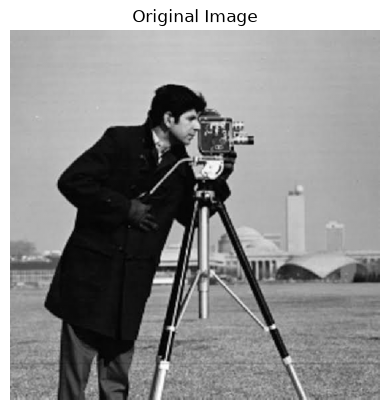

In [11]:
img = cv2.imread("cv-image2.jpeg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [12]:
f = np.fft.fft2(img)

fshift = np.fft.fftshift(f)

In [13]:
rows, cols = img.shape

crow = rows // 2
ccol = cols // 2

mask = np.ones((rows, cols), np.uint8)

mask[crow-30:crow+30,
     ccol-30:ccol+30] = 0

In [14]:
high_freq = fshift * mask

In [15]:
inverse = np.fft.ifftshift(high_freq)

img_back = np.fft.ifft2(inverse)

img_back = np.abs(img_back)

In [22]:
A = 2

high_boost = (A - 1) * img + img_back

high_boost = np.clip(high_boost, 0, 255).astype(np.uint8)

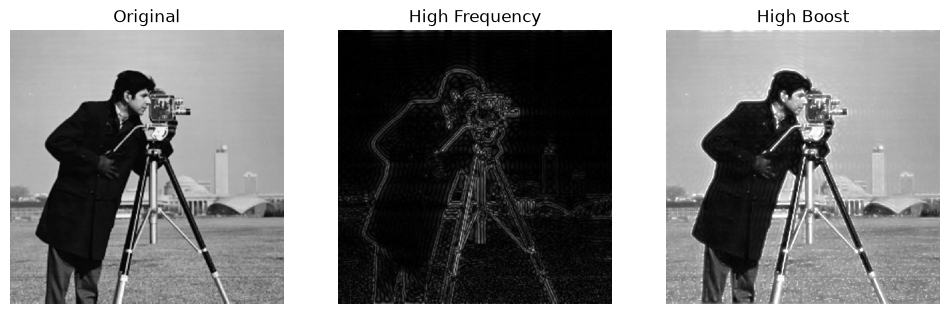

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(img_back, cmap='gray')
plt.title("High Frequency")
plt.axis("off")

plt.subplot(133)
plt.imshow(high_boost, cmap='gray')
plt.title("High Boost")
plt.axis("off")

plt.show()

In [29]:
# Adaptive Local Enhancement: Write a script that applies Gamma correction locally, using
# different γ values for dark and bright sub-regions of an image.
img = cv2.imread("cv-image3.jpeg", cv2.IMREAD_GRAYSCALE)

img = img / 255.0

In [30]:
enhanced = np.zeros_like(img)

In [31]:
for i in range(img.shape[0]):
    for j in range(img.shape[1]):

        if img[i, j] < 0.5:

            enhanced[i, j] = img[i, j] ** 0.5

        else:

            enhanced[i, j] = img[i, j] ** 2

In [32]:
enhanced = (enhanced * 255).astype(np.uint8)

original = (img * 255).astype(np.uint8)

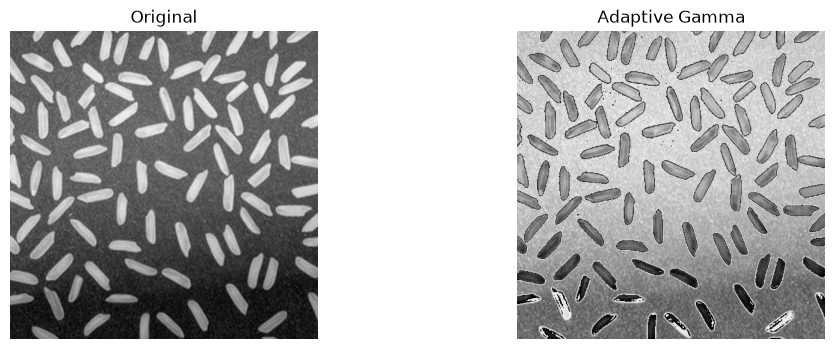

In [33]:
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(enhanced, cmap='gray')
plt.title("Adaptive Gamma")
plt.axis("off")

plt.show()